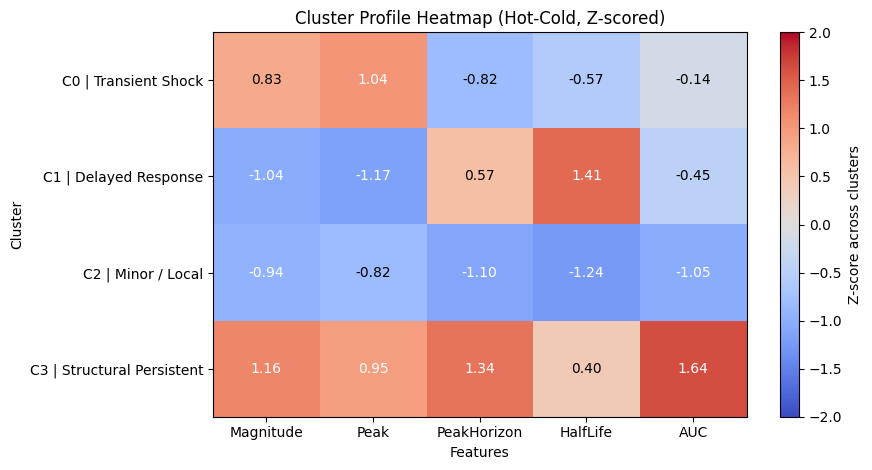

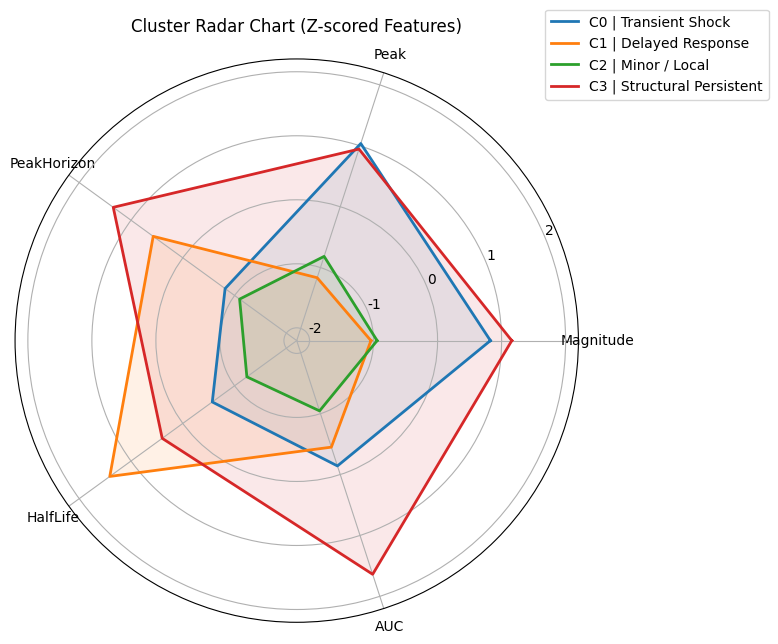

[DONE]
Saved files:
- result\cluster_profile_mean_raw.csv
- result\cluster_profile_mean_zscore.csv
- result\cluster_profile_heatmap_hotcold.png
- result\cluster_profile_radar.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 0. Config
# ============================================================
BASE_DIR = Path("./")
RESULT_DIR = BASE_DIR / "result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = RESULT_DIR / "event_clusters_final.csv"

FEATURES = ["Magnitude", "Peak", "PeakHorizon", "HalfLife", "AUC"]

# ============================================================
# 1. Load
# ============================================================
df = pd.read_csv(INPUT_FILE)

# cluster label 확인용
if "ClusterLabel" in df.columns:
    cluster_label_map = (
        df[["Cluster", "ClusterLabel"]]
        .drop_duplicates()
        .sort_values("Cluster")
        .set_index("Cluster")["ClusterLabel"]
        .to_dict()
    )
else:
    cluster_label_map = {c: f"C{c}" for c in sorted(df["Cluster"].unique())}

# ============================================================
# 2. Cluster mean table
# ============================================================
cluster_mean_raw = (
    df.groupby("Cluster")[FEATURES]
    .mean()
    .sort_index()
)

cluster_mean_raw.index = [
    f"C{c} | {cluster_label_map.get(c, '')}" for c in cluster_mean_raw.index
]

# z-score 표준화: feature별로 cluster 평균 비교용
cluster_mean_z = cluster_mean_raw.copy()
for col in FEATURES:
    mean_ = cluster_mean_z[col].mean()
    std_ = cluster_mean_z[col].std(ddof=0)
    if std_ == 0:
        cluster_mean_z[col] = 0.0
    else:
        cluster_mean_z[col] = (cluster_mean_z[col] - mean_) / std_

# 저장
cluster_mean_raw.to_csv(RESULT_DIR / "cluster_profile_mean_raw.csv", encoding="utf-8-sig")
cluster_mean_z.to_csv(RESULT_DIR / "cluster_profile_mean_zscore.csv", encoding="utf-8-sig")

# ============================================================
# 3. Hot-Cold Heatmap
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4.8))

data = cluster_mean_z.values

im = ax.imshow(data, aspect="auto", cmap="coolwarm", vmin=-2.0, vmax=2.0)

# 축 라벨
ax.set_xticks(np.arange(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=0)
ax.set_yticks(np.arange(len(cluster_mean_z.index)))
ax.set_yticklabels(cluster_mean_z.index)

# 숫자 annotation
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        text_color = "white" if abs(val) >= 0.9 else "black"
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color=text_color, fontsize=10
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Z-score across clusters")

ax.set_title("Cluster Profile Heatmap (Hot-Cold, Z-scored)")
ax.set_xlabel("Features")
ax.set_ylabel("Cluster")

plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_profile_heatmap_hotcold.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 4. Radar Chart
# ============================================================
labels = FEATURES
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for idx in cluster_mean_z.index:
    values = cluster_mean_z.loc[idx, labels].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=idx)
    ax.fill(angles, values, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(-2.2, 2.2)
ax.set_yticks([-2, -1, 0, 1, 2])
ax.set_yticklabels(["-2", "-1", "0", "1", "2"])
ax.set_title("Cluster Radar Chart (Z-scored Features)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10))

plt.tight_layout()
plt.savefig(RESULT_DIR / "cluster_profile_radar.png", dpi=300, bbox_inches="tight")
plt.show()

print("[DONE]")
print("Saved files:")
print("-", RESULT_DIR / "cluster_profile_mean_raw.csv")
print("-", RESULT_DIR / "cluster_profile_mean_zscore.csv")
print("-", RESULT_DIR / "cluster_profile_heatmap_hotcold.png")
print("-", RESULT_DIR / "cluster_profile_radar.png")